Question 1.1

In [2]:
%matplotlib inline
import brian2 as b2
import matplotlib.pyplot as plt
import numpy as np
from neurodynex3.leaky_integrate_and_fire import LIF
from neurodynex3.tools import input_factory, plot_tools

# LIF.getting_started()
LIF.print_default_parameters()

Resting potential: -70. mV
Reset voltage: -65. mV
Firing threshold: -50. mV
Membrane resistance: 10. Mohm
Membrane time-scale: 8. ms
Absolute refractory period: 2. ms


In [3]:
I_min = (LIF.FIRING_THRESHOLD - LIF.V_REST) / LIF.MEMBRANE_RESISTANCE
I_min

2. * namp

nr of spikes: 37


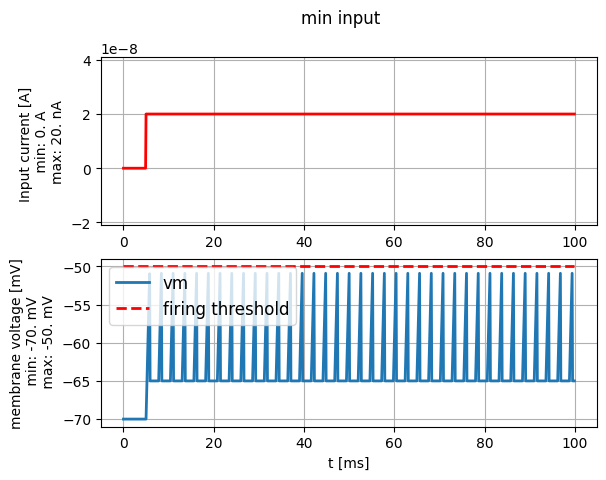

In [18]:
import brian2 as b2
from neurodynex3.leaky_integrate_and_fire import LIF
from neurodynex3.tools import input_factory

# create a step current with amplitude = I_min
step_current = input_factory.get_step_current(
    t_start=5, t_end=100, unit_time=b2.ms,
    # amplitude=I_min)  # set I_min to your value
    amplitude=20*b2.nA)  # set I_min to your value

# run the LIF model.
# Note: As we do not specify any model parameters, the simulation runs with the default values
(state_monitor,spike_monitor) = LIF.simulate_LIF_neuron(input_current=step_current, simulation_time = 100 * b2.ms)

# plot I and vm
plot_tools.plot_voltage_and_current_traces(
state_monitor, step_current, title="min input", firing_threshold=LIF.FIRING_THRESHOLD)
print("nr of spikes: {}".format(spike_monitor.count[0]))  # should be 0


Question 1.2

In [5]:
freq = np.zeros(100)
for i in range(0, 100):
    # create a step current
    step_current = input_factory.get_step_current(
        t_start=0, t_end=500, unit_time=b2.ms,
        amplitude=(i * b2.nA)
    )
    # run the LIF model.
    (state_monitor,spike_monitor) = LIF.simulate_LIF_neuron(input_current=step_current, simulation_time = 500 * b2.ms, abs_refractory_period=3*b2.ms)
    freq[i] = spike_monitor.count[0] * 2
    print(i, spike_monitor.count[0] * 2)

    # plot I and vm
    # plot_tools.plot_voltage_and_current_traces(
    # state_monitor, step_current, title="min input", firing_threshold=LIF.FIRING_THRESHOLD)
    # print("nr of spikes: {}".format(spike_monitor.count[0]))
    # print("spike rate: {}".format(spike_monitor.count[0] / (500*b2.ms)))
print(freq)
plot_tools.plt.plot(np.arange(100), freq)

0 0
1 0
2 0
3 96
4 134
5 160


KeyboardInterrupt: 

Question 1.3

Resting potential: -63. mV
Reset voltage: -55. mV
Firing threshold: -29. mV
Membrane resistance: 5. Mohm
Membrane time-scale: 7. ms
Absolute refractory period: 2. ms

My calculations gave me:
u_rest = -64mV
u_r = -54mV
theta_r = -31mV
R = 4.8 M-Ohms
T_m = 2.1ms



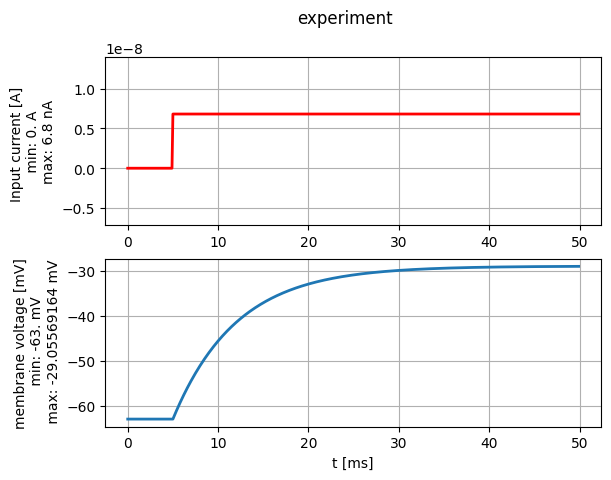

In [55]:
random_params = LIF.get_random_param_set(24)
I = input_factory.get_step_current(
    t_start=5, t_end=55, unit_time=b2.ms,
    amplitude=6.8*b2.nA)  # set I_min to your value

(state_monitor,spike_monitor) = LIF.simulate_random_neuron(input_current=I, obfuscated_param_set=random_params)
plot_tools.plot_voltage_and_current_traces(state_monitor, I, title="experiment")
spike_monitor.count[0]

LIF.print_obfuscated_parameters(random_params)
print("""
My calculations gave me:
u_rest = -64mV
u_r = -54mV
theta_r = -31mV
R = 4.8 M-Ohms
T_m = 2.1ms
""")

Question 1.4

In [ ]:
import scipy
def amp_and_phase(freq = 250):
    sinusoidal_current = input_factory.get_sinusoidal_current(200, 1000, unit_time=0.1 * b2.ms,
                                                amplitude= 2.5 * b2.namp, frequency=freq*b2.Hz,
                                                direct_current=0. * b2.namp)

    # run the LIF model. By setting the firing threshold to to a high value, we make sure to stay in the linear (non spiking) regime.
    (state_monitor, spike_monitor) = LIF.simulate_LIF_neuron(input_current=sinusoidal_current, simulation_time = 120 * b2.ms, firing_threshold=0*b2.mV)

    # plot the membrane voltage
    # plot_tools.plot_voltage_and_current_traces(state_monitor, sinusoidal_current, title="Sinusoidal input current")
    # print("nr of spikes: {}".format(spike_monitor.count[0]))
    V = state_monitor[0].v[500:1000]
    A = sinusoidal_current(state_monitor.t[500:1000], 0)

    amplitude = np.max(V) - np.min(V)

    fs = 10000 # sampling frequency
    freq = 250 # signal frequency
    corr = scipy.signal.correlate(A-np.mean(A),V-np.mean(V),mode="same")
    lags = scipy.signal.correlation_lags(len(A),len(V),mode="same")
    best_lag = lags[np.argmax(corr)]
    # Convert lag in samples to time lag
    time_lag = best_lag / fs
    phase_shift_calculated = (2 * np.pi * freq * time_lag) 
    phase = np.degrees(phase_shift_calculated)

    return (phase, amplitude)

(phase,amplitude) = amp_and_phase()
print("Amp:", amplitude, "Theta:", phase)

Amp: 4.01695348 mV Theta: -90.0


In [99]:
amps = []
phases = []
freqs = [10, 50, 100, 200, 300, 500, 700, 1000]
for i in range(0,1000,50):
    a,p = amp_and_phase(i)
    amps.append(a)
    phases.append(p)

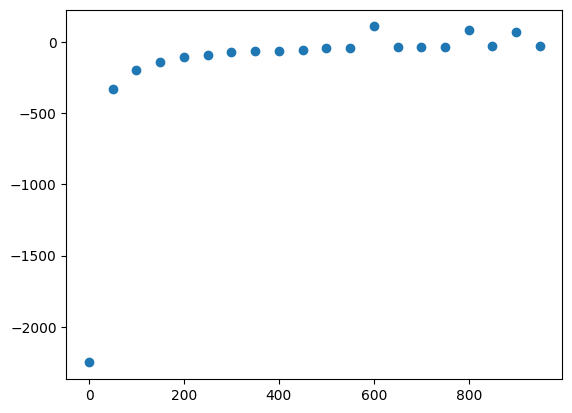

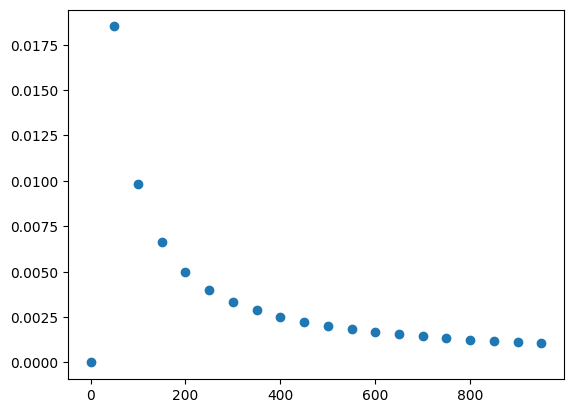

In [101]:
plt.scatter(range(0,1000,50),amps)
plt.show()
plt.scatter(range(0,1000,50),phases)
plt.show()
# print(len(amp))